# FigHeatCool_TeXi — electron & radiation temperature and ionized fraction vs depth

Radial profiles of the electron temperature $T_e$ (panel a) and the hydrogen ionized fraction
$n_{\rm HII}/n_{\rm H}$ (panel b) for the two wind families at $\dot M = 2.5,5,10,20\,M_\odot$/yr.
Colour encodes family (**marginally-unbound** `dilute_redd`, orange; **photon-tired** $f{=}0.94$ ($\Gamma_0{=}1.21$),
blue); line style encodes $\dot M$. The x-axis is $r/r_{\rm Edd}$. Poorly-converged
(converge$\neq0$) cells are drawn faded so the curves stay continuous.

In [1]:
import os, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator

# ================= config: edit here to point at your data / output =================
# (self-contained per notebook for now; lift this block into a shared repro_paths.py
#  once the final matrix_pow + custom-band reruns exist and dirs are unified.)
DATA_ROOT = os.environ.get("SIROCCO_REPRO_DATA", "/scratch/gpfs/nk6352/sirocco_runs")
FIG_DIR   = os.path.abspath("../figures")           # where this notebook writes its PDF/PNG
RUN_SET   = os.environ.get("SIROCCO_REPRO_RUNSET", "repro")   # "legacy" (paper freeze) | "repro" (repro/ reruns)
# NOTE: repro/ runs = matrix_pow + Photon_sampling=wide. Photon-tired family = ptf_*
#   (f=0.94 tiring fraction, Gamma_0=1.2128 Owocki+2017 winds), superseding the legacy
#   g1.38 pt_* family; all four ptf runs completed & health-checked 2026-08-13.
#   ptf m10/m20 unconverged cells lie beyond the H recombination front (t_e collapse in
#   decoupled neutral gas; converged inside), so SPECTRA come from the *_trunc_speconly
#   extraction reruns where noted, while wind-structure tables read the parent dirs.
#   Verified 2026-08-11 against the legacy matrix_bb runs: mu_* AND pt_* are healthy
#   (the earlier matrix_pow pt_* under-ionization is gone; e.g. pt_m5 mid-wind h1~6e-4,
#   matching legacy ~5e-4). Integrated 2000-10000 A flux matches legacy to <~8% for all
#   runs except pt_m20 (0.42x the legacy g1.38_hires run; m20 is the known poorly-converged
#   case, and the gallery takes its m20 spectra from the *_trunc_speconly reruns).
RUN_DIRS_LEGACY  = {"MU_m2.5": "1d_m2.5_dilute_redd_hires", "MU_m5":  "1d_m5_dilute_redd",
             "MU_m10":  "1d_m10_dilute_redd",        "MU_m20": "1d_m20_dilute_redd",
             "PT_m2.5": "photon_tired_winds/m2.5_g1.38_hires", "PT_m5":  "photon_tired_winds/m5_g1.38_hires",
             "PT_m10":  "photon_tired_winds/m10_g1.38_hires",  "PT_m20": "photon_tired_winds/m20_g1.38_hires"}
RUN_DIRS_REPRO = {"MU_m2.5": "repro/mu_m2.5", "MU_m5": "repro/mu_m5",
                   "MU_m10": "repro/mu_m10", "MU_m20": "repro/mu_m20",
                   "PT_m2.5": "repro/ptf_m2.5", "PT_m5": "repro/ptf_m5",
                   "PT_m10": "repro/ptf_m10", "PT_m20": "repro/ptf_m20"}
RUN_DIRS  = {"legacy": RUN_DIRS_LEGACY, "repro": RUN_DIRS_REPRO}[RUN_SET]
def run_path(k): return os.path.join(DATA_ROOT, RUN_DIRS[k])
os.makedirs(FIG_DIR, exist_ok=True)

# ---- manuscript style ----
plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.family': 'serif', 'mathtext.fontset': 'dejavuserif',
    'font.size': 9, 'axes.titlesize': 10, 'axes.labelsize': 10,
    'axes.linewidth': 0.8, 'lines.linewidth': 1.0,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
})
# ====================================================================================

MDOTS = ['m2.5', 'm5', 'm10', 'm20']

def load_heat(rd):
    "Inwind (converged-geometry) rows of the per-cell heat/cool table."
    h = pd.read_csv(f'{rd}/outflow.heat.txt', sep=r'\s+'); return h[h['inwind'] == 0].reset_index(drop=True)

# Larger, readable fonts for single-column placement in a 2-column PDF.
FONT_SCALE = {
    'font.family':     'serif',
    'mathtext.fontset':'dejavuserif',
    'font.size':       22,
    'axes.labelsize':  26,
    'axes.titlesize':  26,
    'xtick.labelsize': 22,
    'ytick.labelsize': 22,
    'legend.fontsize': 18,
    'xtick.major.size': 8, 'xtick.minor.size': 4,
    'ytick.major.size': 8, 'ytick.minor.size': 4,
    'lines.linewidth': 2.6,
}

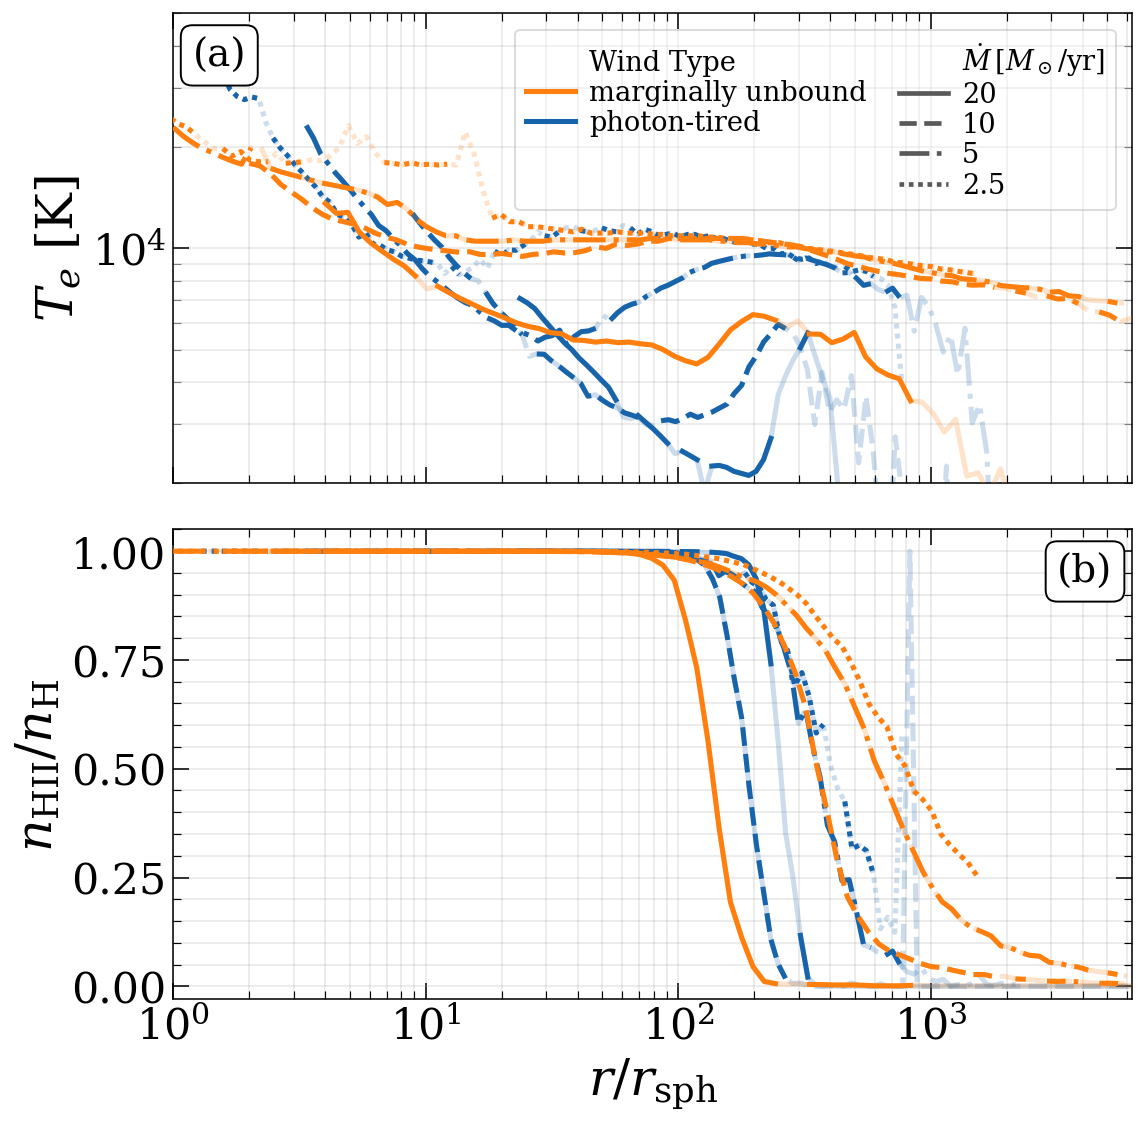

In [2]:
# Stacked (2x1) — Te and ionized fraction vs r/r_Edd.
# colour = family (marginally unbound orange / photon-tired f=0.94 (Gamma_0=1.21) blue); linestyle = Mdot;
# Unconverged cells are drawn FADED (not blanked) so lines stay continuous.
PT_COLOR = plt.cm.Blues(0.8)
MB_COLOR = 'tab:orange'
R_ref    = 8e14 * (10.0 / 5.0)                  # r_Edd normalisation (same as the v/rho figure)
LS_M     = {'m2.5':(0,(1,1)), 'm5':'-.', 'm10':'--', 'm20':'-'}   # 2.5 dotted ... 20 solid
FADE     = 0.22                                  # opacity for poorly-converged (converge!=0) cells

def fplot(ax, x, y, good, **kw):                # faded underlay everywhere + crisp overlay on converged cells
    a = kw.pop('alpha', 1.0)
    ax.plot(x, y, alpha=FADE*a, **kw)
    ax.plot(x, np.where(good, y, np.nan), alpha=a, **kw)

def load_prof2(rd):                             # r/r_Edd, Te, ionized fraction, converged mask (values kept)
    h = load_heat(rd)
    m = pd.read_csv(f'{rd}/outflow.master.txt', sep=r'\s+'); m = m[m['inwind']==0].reset_index(drop=True)
    n = min(len(h), len(m)); h = h.iloc[:n].reset_index(drop=True); m = m.iloc[:n].reset_index(drop=True)
    o = np.argsort(h['r'].values); cv = (h['converge'].values == 0)[o]
    rr = h['r'].values[o] / R_ref
    Te = h['t_e'].values[o].astype(float)
    xi = 1.0 - m['h1'].values[o]
    return dict(r=rr, Te=Te, xi=xi, cv=cv)

with plt.rc_context(FONT_SCALE):
    fig, (axT, axX) = plt.subplots(2, 1, figsize=(8.5, 8.5), sharex=True)

    for md in MDOTS:                                # photon-tired Gamma_0 = 1.21 (f=0.94)
        c = load_prof2(run_path('PT_'+md)); ls = LS_M[md]
        fplot(axT, c['r'], c['Te'], c['cv'], color=PT_COLOR, ls=ls, lw=2.6)
        fplot(axX, c['r'], c['xi'], c['cv'], color=PT_COLOR, ls=ls, lw=2.6)

    for md in MDOTS:                                # marginally unbound on top
        c = load_prof2(run_path('MU_'+md)); ls = LS_M[md]
        fplot(axT, c['r'], c['Te'], c['cv'], color=MB_COLOR, ls=ls, lw=2.6, zorder=3)
        fplot(axX, c['r'], c['xi'], c['cv'], color=MB_COLOR, ls=ls, lw=2.6, zorder=3)

    axT.set(xscale='log', yscale='log', ylabel=r'$T_e$ [K]',
            xlim=(1.0, 1e19 / R_ref), ylim=(2e3, 5e4))
    axX.set(xscale='log', xlabel=r'$r/r_{\rm sph}$',
            ylabel=r'$n_{\rm HII}/n_{\rm H}$',
            xlim=(1.0, 1e19 / R_ref), ylim=(-0.03, 1.05))
    for ax in (axT, axX):
        ax.grid(alpha=0.3, which='both', zorder=0)
    axT.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10), numticks=100))
    axT.tick_params(axis='y', which='minor', length=4, color='gray')

    # 2-column legend tucked inside panel (a), column-major fill, 5 rows each:
    #   col1 = family header + 2 colours (+2 pad);  col2 = Mdot header + 4 line styles.
    hdr = lambda label: Line2D([0], [0], color='none', linewidth=0, marker='', label=label)
    handles = [
        hdr('Wind Type'),
        Line2D([0], [0], color=MB_COLOR, lw=2.6, label='marginally unbound'),
        Line2D([0], [0], color=PT_COLOR, lw=2.6, label=r'photon-tired'),
        hdr(''), hdr(''),
        hdr(r'$\dot{M}\,[M_\odot/\mathrm{yr}]$'),
        *[Line2D([0], [0], color='0.35', lw=2.4, linestyle=LS_M[md],
                 label=md.replace('m', '')) for md in reversed(MDOTS)],
    ]
    leg = axT.legend(handles=handles, ncol=2, loc='upper right',
                     fontsize=14, framealpha=0.35, columnspacing=1.2, handlelength=1.8,
                     handletextpad=0.5, borderaxespad=0.6, labelspacing=0.12)
    leg.get_frame().set_edgecolor('0.6')

    axT.text(0.02, 0.95, '(a)', transform=axT.transAxes, fontsize=20,
             ha='left', va='top', bbox=dict(facecolor='white', boxstyle="round"))
    axX.text(0.98, 0.95, '(b)', transform=axX.transAxes, fontsize=20,
             ha='right', va='top', bbox=dict(facecolor='white', boxstyle="round"))

    plt.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, 'FigHeatCool_TeXi.pdf'))
    fig.savefig(os.path.join(FIG_DIR, 'FigHeatCool_TeXi.png'), dpi=300)
    plt.show()